In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cmaps
import sys
import os
from pathlib import Path

# 导入wave_tools工具
WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
from wave_tools.plotting import get_cckw_envelope_curve

print("✅ 模块导入成功")

✅ 模块导入成功


In [6]:
# ============ 配置参数 ============

# 数据路径
DATA_PATH = "fig11/crossspectrum_pr_div_pressure_levels.npz"

# 输出目录
FIG_SAVE_DIR = "../fig/"
os.makedirs(FIG_SAVE_DIR, exist_ok=True)

# 物理常数
s2d = 86400  # 秒到天的转换
re = 6.371e6  # 地球半径（米）

# 实验设置
EXPERIMENTS = ['cntl', 'p4k', '4co2']
EXP_TITLES = ['CNTL', 'P4K', '4CO2']
PRESSURE_LEVELS = [250, 500, 850]  # hPa

print(f"输出目录: {FIG_SAVE_DIR}")
print(f"气压层: {PRESSURE_LEVELS} hPa")
print(f"实验: {EXPERIMENTS}")

输出目录: ../fig/
气压层: [250, 500, 850] hPa
实验: ['cntl', 'p4k', '4co2']


In [7]:
# ============ 加载预计算的交叉谱数据 ============

print(f"加载数据: {DATA_PATH}")
data_raw = np.load(r'/work/mh1498/m301257/Plot_data/fig11/crossspectrum_pr_div_pressure_levels.npz', allow_pickle=True)

# 重构数据结构
crossspectrum_results = {}
for exp_name in EXPERIMENTS:
    crossspectrum_results[exp_name] = {}
    for plev in PRESSURE_LEVELS:
        key = f"{exp_name}_{plev}"
        if key in data_raw:
            crossspectrum_results[exp_name][plev] = data_raw[key].item()

print("\n✅ 数据加载成功！")
print(f"   实验: {list(crossspectrum_results.keys())}")
print(f"   气压层: {list(crossspectrum_results['cntl'].keys())}")

# 验证数据
sample = crossspectrum_results['cntl'][250]
print(f"\n数据结构示例 (CNTL, 250 hPa):")
print(f"   Keys: {list(sample.keys())}")
print(f"   STC shape: {sample['STC'].shape}")
print(f"   99% 显著性阈值: {sample['prob_coh2']}")

加载数据: fig11/crossspectrum_pr_div_pressure_levels.npz

✅ 数据加载成功！
   实验: ['cntl', 'p4k', '4co2']
   气压层: [250, 500, 850]

数据结构示例 (CNTL, 250 hPa):
   Keys: ['STC', 'freq', 'wave', 'nseg', 'dof', 'p', 'prob_coh2']
   STC shape: (8, 49, 167)
   99% 显著性阈值: [0.00719033 0.00847012 0.01027109 0.01154691 0.01334228 0.02043668]


In [8]:
# ============ 辅助函数：添加参考线 ============

def add_reference_lines(ax):
    """
    添加参考线到交叉谱图：
    - CCKW 波段
    - 周期线（3天、6天、20天）
    - Kelvin 波色散关系
    - 零波数线
    """
    # CCKW 波段
    kw_x, kw_y = get_cckw_envelope_curve()
    ax.plot(kw_x[0], kw_y[0], 'red', linewidth=1.5, linestyle='solid', label='CCKW band')
    
    # 周期线
    d = np.array([3, 6, 20])
    dname = ['3d', '6d', '20d']
    
    # 零波数线
    ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':')
    
    for dd in range(len(d)):
        ax.plot([-15, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=1, linestyle=':')
        ax.text(-14.8, 1/d[dd] + 0.01, dname[dd], fontsize=15, color='k')
    
    # Kelvin 波色散关系
    he_all = np.array([8, 25, 90])  # 等效深度 (m)
    cp = (9.8 * he_all) ** 0.5  # 相速度
    zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re
    
    for hh in range(len(he_all)):
        ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1, linestyle='dashed')
    
    # Kelvin 标签
    ax.text(12, 0.35, 'kelvin', ha="center", va="center", size=9,
            bbox={'facecolor': 'w', 'alpha': 0.9, 'edgecolor': 'none'})

print("✅ 辅助函数定义完成")

✅ 辅助函数定义完成


✅ 主绘图函数定义完成

绘制 250 hPa 气压层的交叉谱图 (99% 显著性检验)
  CNTL: 99%显著性阈值 = 0.020437
     通过99%显著性检验: 3072/8183 (37.5%)
     绘制了 737 个有效矢量
  P4K: 99%显著性阈值 = 0.020437
     通过99%显著性检验: 1443/8183 (17.6%)
     绘制了 341 个有效矢量
  4CO2: 99%显著性阈值 = 0.020437
     通过99%显著性检验: 2725/8183 (33.3%)
     绘制了 678 个有效矢量

✅ 图片已保存: ../fig/fig11_cross_spectrum_pr_div_250hpa_99sig.png


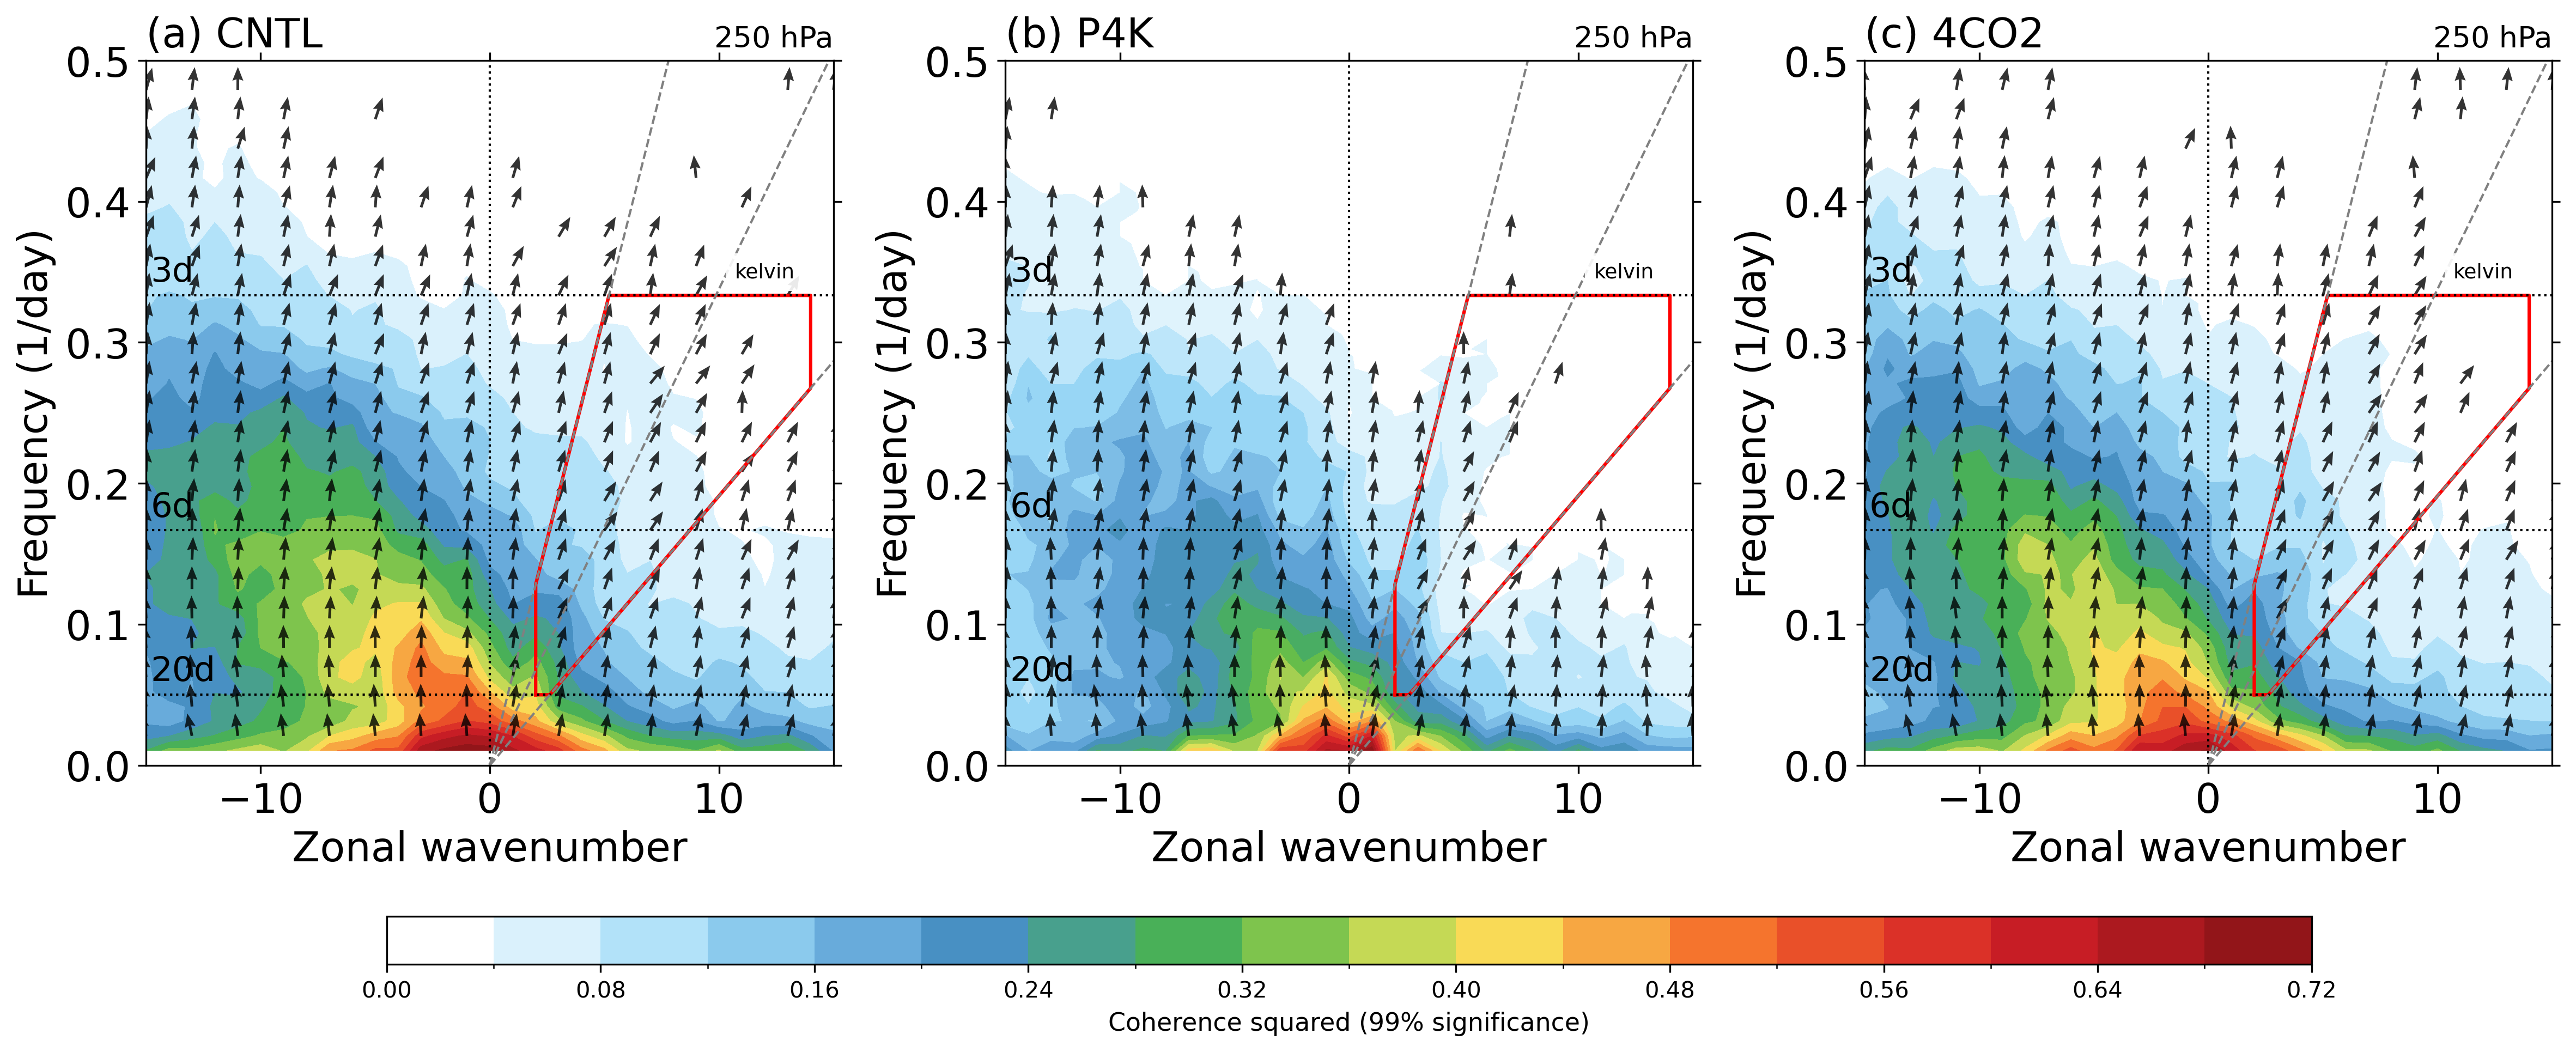


绘制 500 hPa 气压层的交叉谱图 (99% 显著性检验)
  CNTL: 99%显著性阈值 = 0.020437
     通过99%显著性检验: 240/8183 (2.9%)
     绘制了 56 个有效矢量
  P4K: 99%显著性阈值 = 0.020437
     通过99%显著性检验: 249/8183 (3.0%)
     绘制了 58 个有效矢量
  4CO2: 99%显著性阈值 = 0.020437
     通过99%显著性检验: 288/8183 (3.5%)
     绘制了 64 个有效矢量

✅ 图片已保存: ../fig/fig11_cross_spectrum_pr_div_500hpa_99sig.png


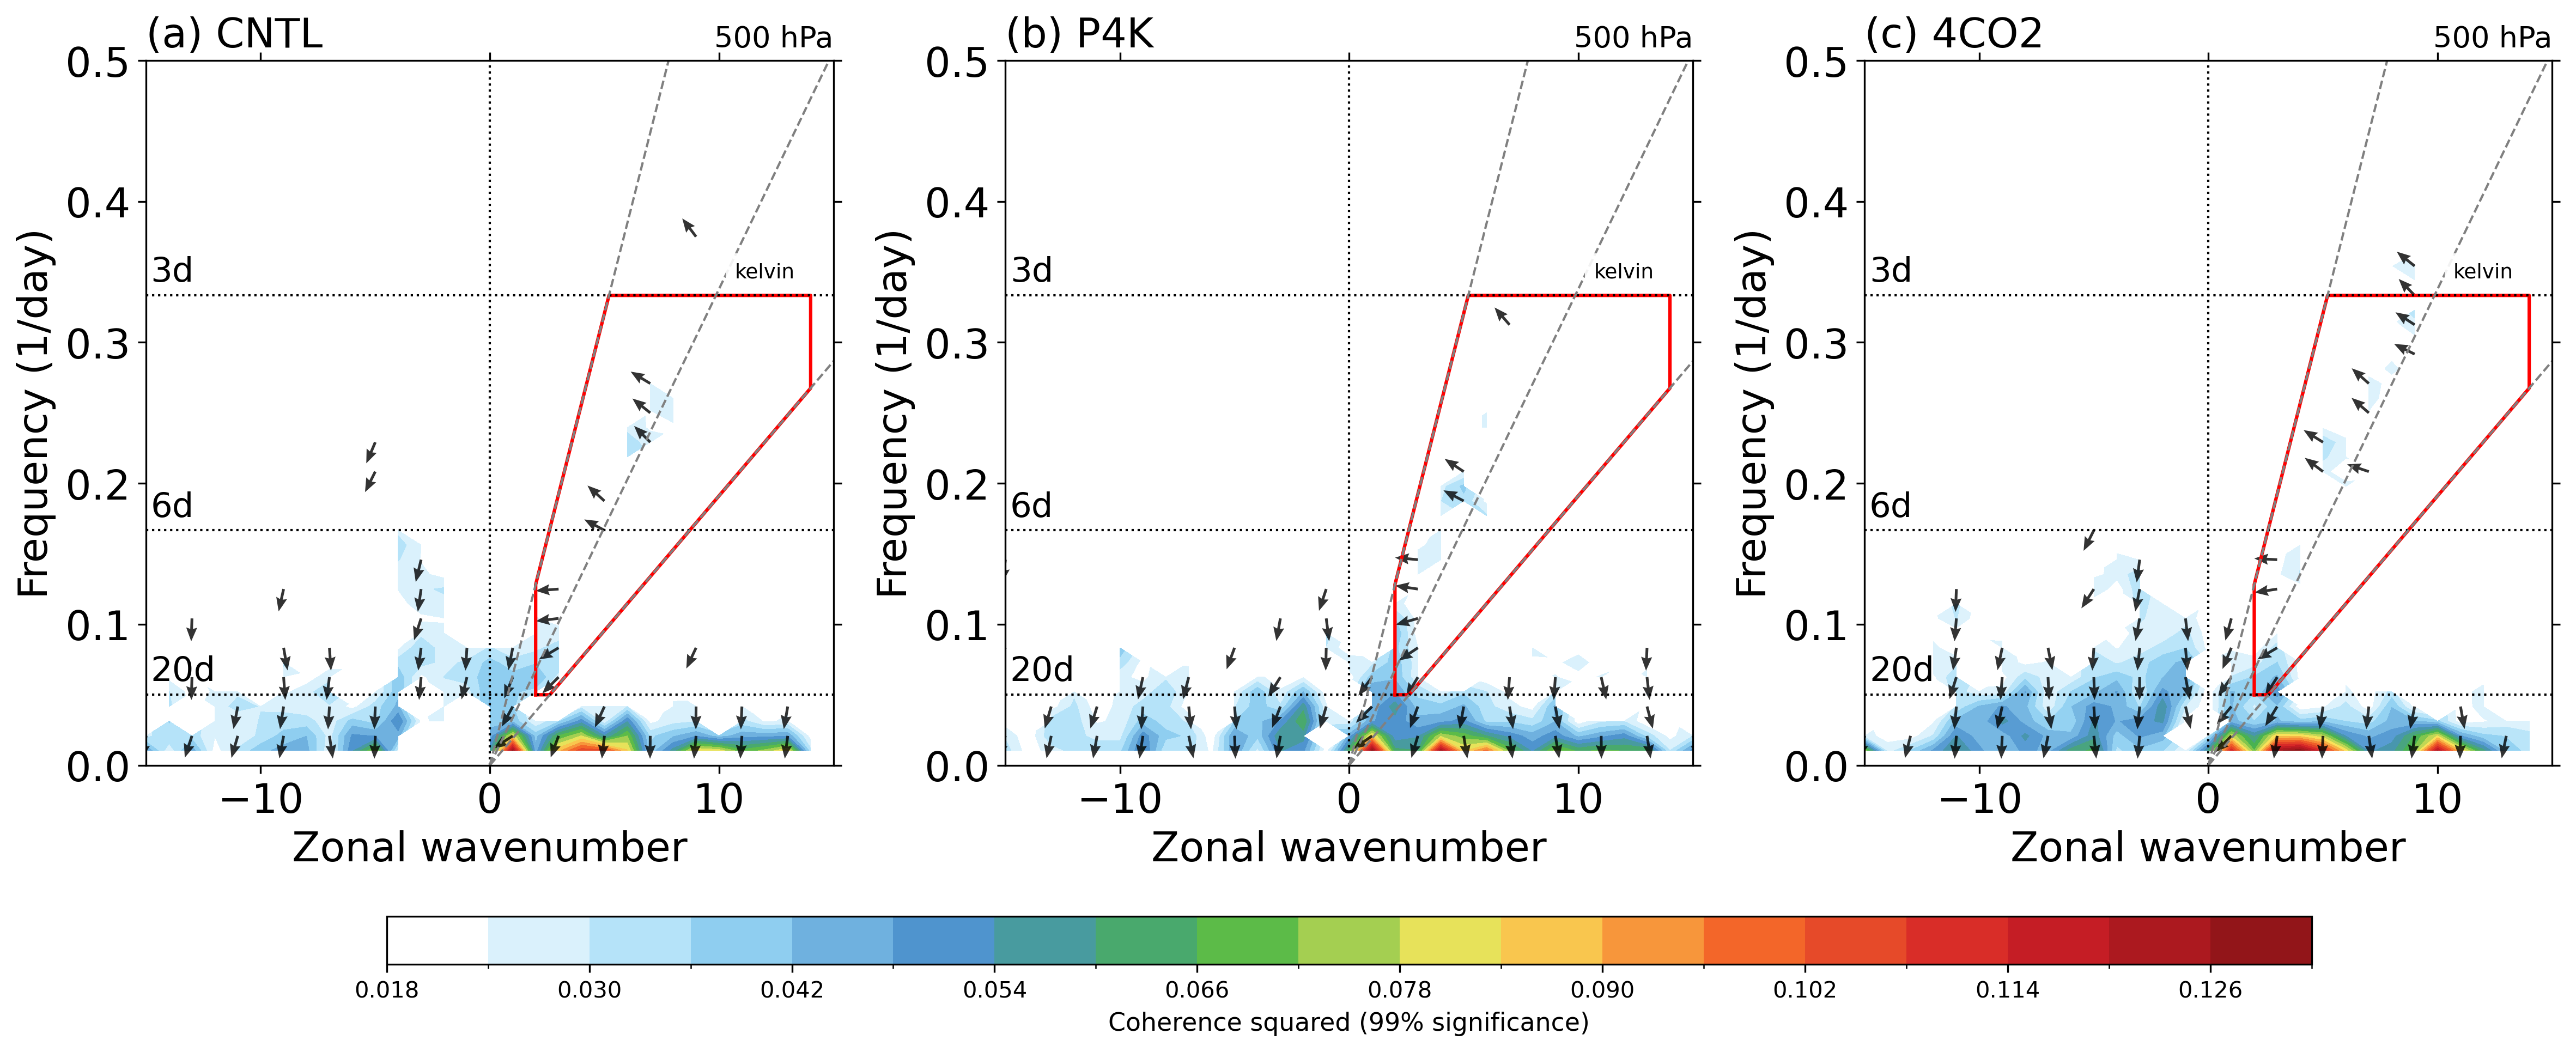


绘制 850 hPa 气压层的交叉谱图 (99% 显著性检验)
  CNTL: 99%显著性阈值 = 0.020437
     通过99%显著性检验: 845/8183 (10.3%)
     绘制了 203 个有效矢量
  P4K: 99%显著性阈值 = 0.020437
     通过99%显著性检验: 564/8183 (6.9%)
     绘制了 143 个有效矢量
  4CO2: 99%显著性阈值 = 0.020437
     通过99%显著性检验: 727/8183 (8.9%)
     绘制了 186 个有效矢量

✅ 图片已保存: ../fig/fig11_cross_spectrum_pr_div_850hpa_99sig.png


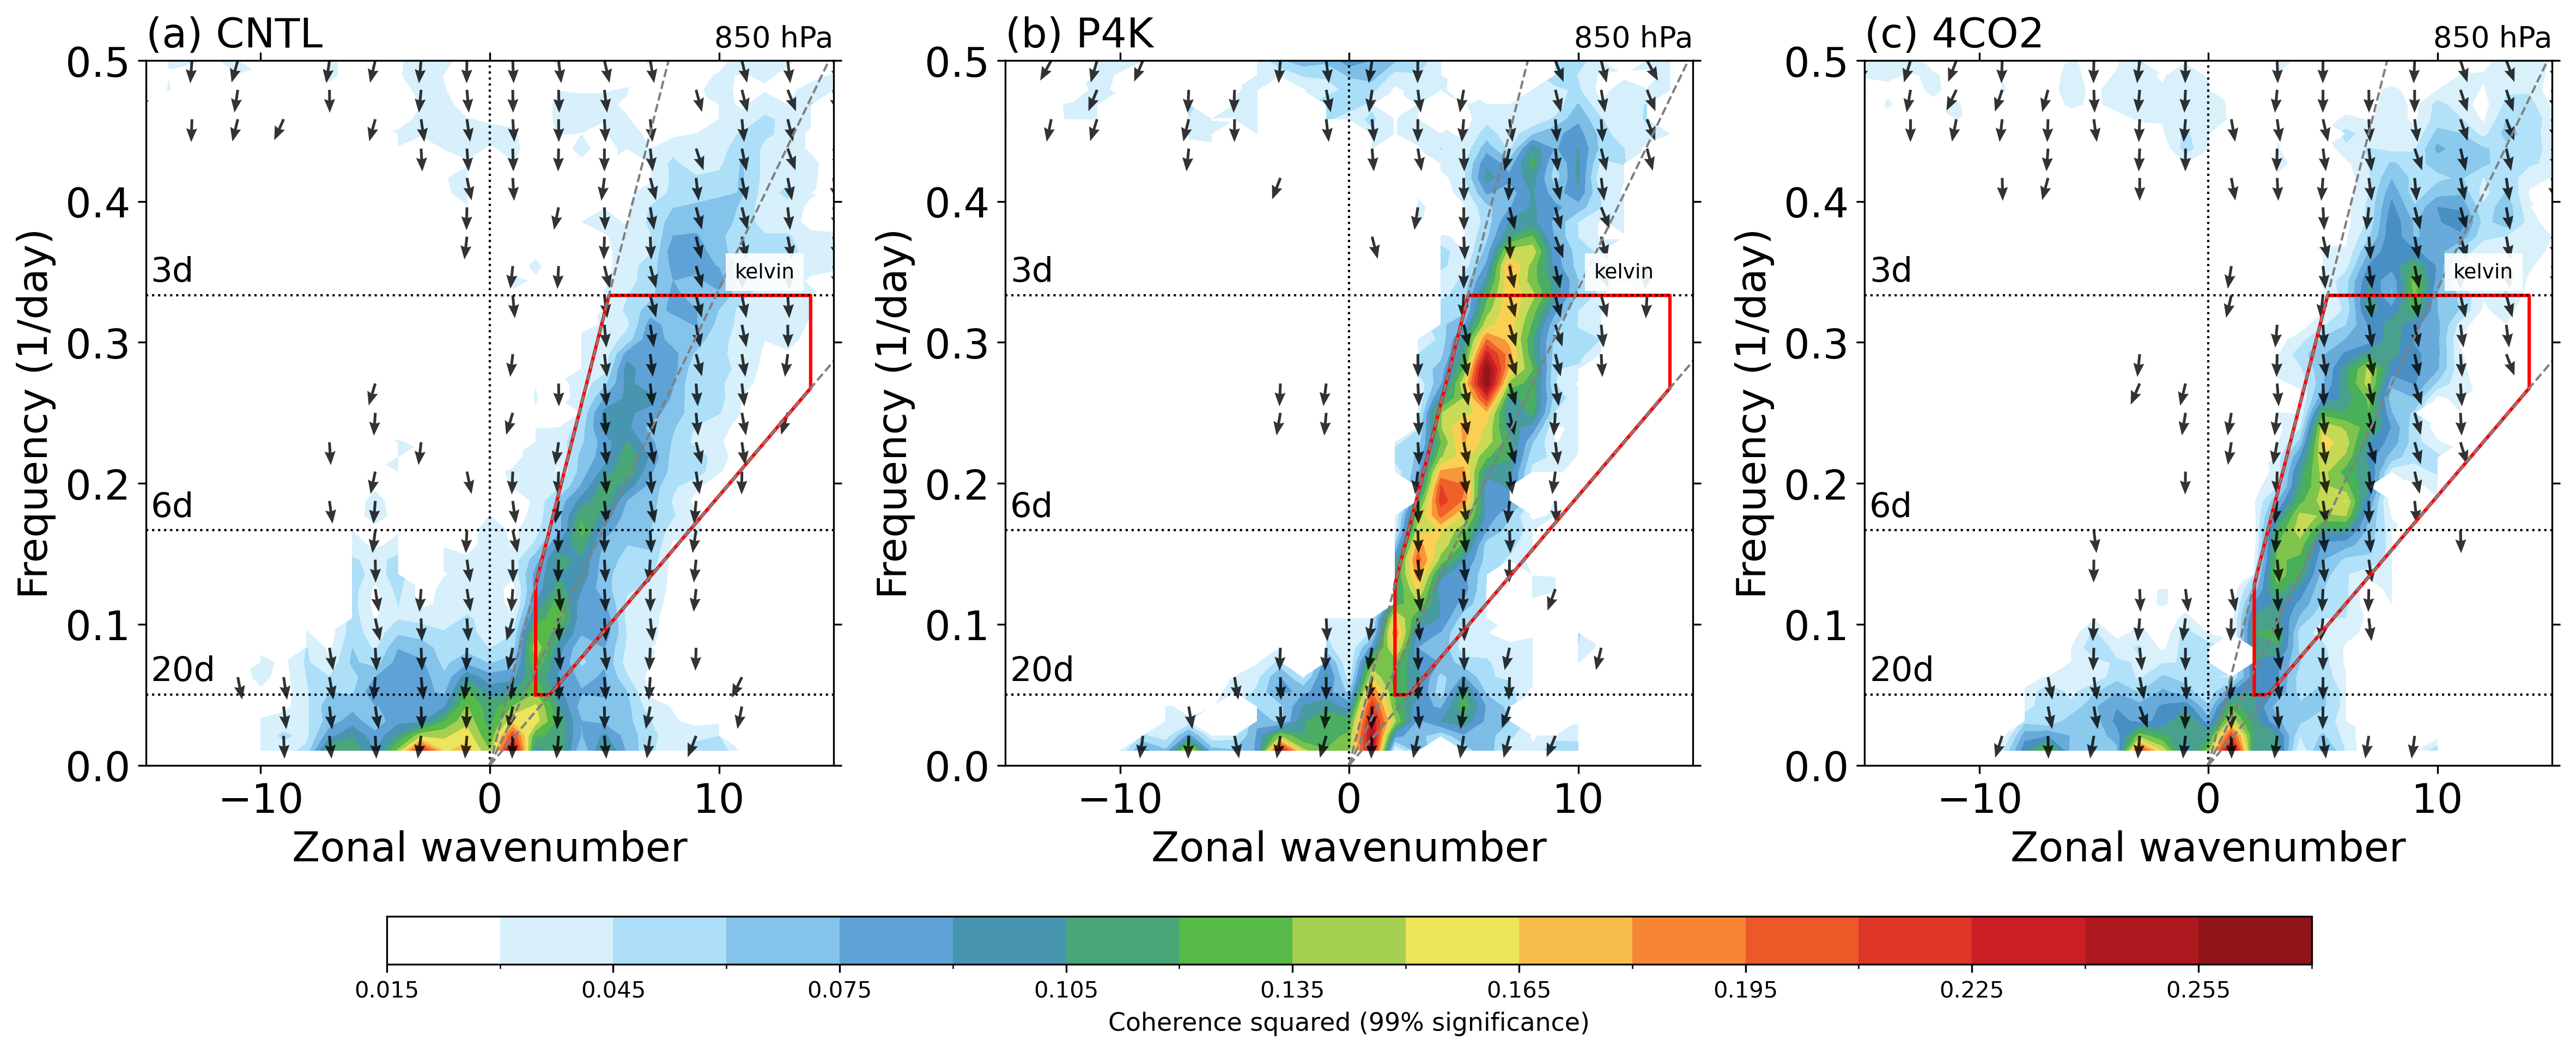


✅ 所有 3 个气压层的图片生成完成！

保存位置: ../fig/
  - cross_spectrum_pr_div_250hpa_99sig.png
  - cross_spectrum_pr_div_500hpa_99sig.png
  - cross_spectrum_pr_div_850hpa_99sig.png


In [9]:
# ============ 主绘图函数 ============

def plot_cross_spectrum_pressure_level(crossspectrum_results, plev, save_dir):
    """
    为指定气压层生成交叉谱图（使用99%显著性检验）
    
    Parameters:
    -----------
    crossspectrum_results : dict
        包含所有实验和气压层的交叉谱数据
    plev : int
        气压层 (hPa)
    save_dir : str
        保存图片的目录
    """
    print(f"\n{'='*60}")
    print(f"绘制 {plev} hPa 气压层的交叉谱图 (99% 显著性检验)")
    print(f"{'='*60}")
    
    # 设置样式
    plt.rcParams.update({'font.size': 10})
    
    # 创建图形
    fig, axes = plt.subplots(1, 3, figsize=(16, 8), dpi=300)
    plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.15, wspace=0.25)
    
    # 存储contourf对象用于colorbar
    contourf_list = []
    
    for idx, (exp_name, exp_title, ax) in enumerate(zip(EXPERIMENTS, EXP_TITLES, axes)):
        plt.sca(ax)
        
        # 获取数据
        result = crossspectrum_results[exp_name][plev]
        stc = result['STC']
        zonalwnum = result['wave']
        freq = result['freq']
        
        # 🔑 获取99%显著性阈值
        coh2_99_threshold_array = result['prob_coh2']
        
        # 处理不同类型的阈值数据
        if isinstance(coh2_99_threshold_array, np.ndarray) and coh2_99_threshold_array.size > 1:
            coh2_99_threshold = float(coh2_99_threshold_array.max())
        elif hasattr(coh2_99_threshold_array, 'item'):
            coh2_99_threshold = float(coh2_99_threshold_array.item())
        else:
            coh2_99_threshold = float(coh2_99_threshold_array)
        
        print(f"  {exp_name.upper()}: 99%显著性阈值 = {coh2_99_threshold:.6f}")
        
        # 获取 coherence squared 数据
        try:
            coh2_data = stc.sel(component='COH2')
        except:
            coh2_data = stc.isel(component=2)
        
        # 统计通过显著性检验的点
        n_significant = int((coh2_data >= coh2_99_threshold).sum())
        total_points = coh2_data.size
        print(f"     通过99%显著性检验: {n_significant}/{total_points} ({100*n_significant/total_points:.1f}%)")
        
        # 🔑 应用99%显著性检验掩蔽
        coh2_data_masked = coh2_data.where(coh2_data >= coh2_99_threshold)
        
        # 绘制等高线图
        try:
            contourf = coh2_data_masked.plot.contourf(
                ax=ax,
                cmap=cmaps.WhiteBlueGreenYellowRed,
                levels=21,
                add_colorbar=False,
                add_labels=False,
                extend='neither'
            )
            contourf_list.append(contourf)
        except Exception as e:
            print(f"     ⚠️  无法绘制等高线: {e}")
            try:
                contourf = ax.pcolormesh(
                    zonalwnum, freq, coh2_data_masked,
                    cmap=cmaps.WhiteBlueGreenYellowRed,
                    shading='auto'
                )
                contourf_list.append(contourf)
            except Exception as e2:
                print(f"     ❌ 也无法绘制pcolormesh: {e2}")
        
        # 准备矢量场数据
        skip = 2
        wave_sub = zonalwnum[::skip]
        freq_sub = freq[::skip]
        
        try:
            u_sub = stc.sel(component='V1').values[::skip, ::skip]
            v_sub = stc.sel(component='V2').values[::skip, ::skip]
            coh2_sub = stc.sel(component='COH2').values[::skip, ::skip]
        except:
            u_sub = stc.isel(component=0).values[::skip, ::skip]
            v_sub = stc.isel(component=1).values[::skip, ::skip]
            coh2_sub = stc.isel(component=2).values[::skip, ::skip]
        
        # 🔑 用99%显著性阈值掩蔽矢量场
        mask = coh2_sub < coh2_99_threshold
        u_masked = np.where(mask, np.nan, u_sub)
        v_masked = np.where(mask, np.nan, v_sub)
        
        # 绘制矢量场
        n_valid_vectors = np.sum(~np.isnan(u_masked))
        if n_valid_vectors > 0:
            try:
                ax.quiver(
                    wave_sub, freq_sub,
                    u_masked, v_masked,
                    scale=30, headwidth=4, headlength=5,
                    width=0.004, alpha=0.8
                )
                print(f"     绘制了 {n_valid_vectors} 个有效矢量")
            except Exception as e:
                print(f"     ⚠️  无法绘制矢量场: {e}")
        
        # 设置标题和坐标轴
        ax.set_title(f'({chr(97 + idx)}) {exp_title}', fontsize=18, loc='left')
        ax.set_title(f'{plev} hPa', fontsize=13, loc='right')
        ax.set_ylabel('Frequency (1/day)', fontsize=18)
        ax.set_xlabel('Zonal wavenumber', fontsize=18)
        ax.set_xlim(-15, 15)
        ax.set_ylim(0, 0.5)
        ax.tick_params(labelsize=18, which='both', top=True, right=True)
        
        # 添加参考线
        add_reference_lines(ax)
    
    # 添加颜色条
    if contourf_list:
        cbar = fig.colorbar(contourf_list[0], ax=axes, orientation='horizontal',
                           pad=0.15, aspect=40, shrink=0.8)
        cbar.set_label(r'Coherence squared (99% significance)', fontsize=11)
    
    # 保存图片
    output_path = os.path.join(save_dir, f'fig11_cross_spectrum_pr_div_{plev}hpa_99sig.png')
    fig.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"\n✅ 图片已保存: {output_path}")
    
    plt.show()
    plt.close(fig)

print("✅ 主绘图函数定义完成")
# ============ 生成所有气压层的图片 ============

for plev in PRESSURE_LEVELS:
    plot_cross_spectrum_pressure_level(crossspectrum_results, plev, FIG_SAVE_DIR)

print("\n" + "="*60)
print(f"✅ 所有 {len(PRESSURE_LEVELS)} 个气压层的图片生成完成！")
print("="*60)
print(f"\n保存位置: {FIG_SAVE_DIR}")
for plev in PRESSURE_LEVELS:
    print(f"  - cross_spectrum_pr_div_{plev}hpa_99sig.png")